### 1. Import Libraries

In [ ]:
!pip install datasets -q

In [ ]:
# ==========================================
# Task 1 : Import Required Libraries
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

from datasets import load_dataset

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import random
import time

### 2. Device Configuration and Reproducibility

In [ ]:
# ==========================================
# Task 1.1 : Device Configuration and Reproducibility
# ==========================================

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("DEVICE CONFIGURATION")
print("=" * 60)
print("Using device :", device)
if torch.cuda.is_available():
    print("GPU Name     :", torch.cuda.get_device_name(0))

DEVICE CONFIGURATION
Using device : cuda
GPU Name     : Tesla T4


### 3. Load and Prepare CIFAR-10 Dataset (Task 1)

The ResNet50 backbone used later in this experiment is pretrained on ImageNet, whichmeans it expects 224x224 RGB input. The native CIFAR-10 images are only 32x32, so everyimage is resized to 224x224 as part of the transform pipeline below, in addition to beingnormalized using the standard ImageNet channel-wise mean and standard deviation. Withoutthis resizing step, the pretrained convolutional filters would not be usable on CIFAR-10 atits native resolution, and the benefit of transfer learning would be lost.

In [ ]:
# ==========================================
# Task 1.2 : Load CIFAR-10 from Hugging Face Hub
# ==========================================

cifar10 = load_dataset("uoft-cs/cifar10")

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("=" * 60)
print("CIFAR-10 DATASET LOADED FROM HUGGING FACE HUB")
print("=" * 60)
print("Train split size :", len(cifar10["train"]))
print("Test split size  :", len(cifar10["test"]))
print("Original Image   :", cifar10["train"][0]["img"].size)

README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  120MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 23.9MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

CIFAR-10 DATASET LOADED FROM HUGGING FACE HUB
Train split size : 50000
Test split size  : 10000
Original Image   : (32, 32)


In [ ]:
# ==========================================
# Task 1.3 : Custom Dataset Class with Transform Pipeline
# ==========================================

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

transform_pipeline = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

class CIFAR10HFDataset(Dataset):
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, index):
        sample = self.hf_split[index]
        image = sample["img"].convert("RGB")
        label = sample["label"]
        image = self.transform(image)
        return image, label

train_dataset = CIFAR10HFDataset(cifar10["train"], transform_pipeline)
test_dataset = CIFAR10HFDataset(cifar10["test"], transform_pipeline)

sample_image, sample_label = train_dataset[0]

print("=" * 60)
print("DATASET WRAPPED IN CUSTOM PYTORCH DATASET")
print("=" * 60)
print("Training Samples      :", len(train_dataset))
print("Testing Samples       :", len(test_dataset))
print("Image Shape (resized) :", tuple(sample_image.shape))
print("Number of Classes     :", len(class_names))
print("Class Names           :", class_names)

DATASET WRAPPED IN CUSTOM PYTORCH DATASET
Training Samples      : 50000
Testing Samples       : 10000
Image Shape (resized) : (3, 224, 224)
Number of Classes     : 10
Class Names           : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### 4. Display Ten Sample Images

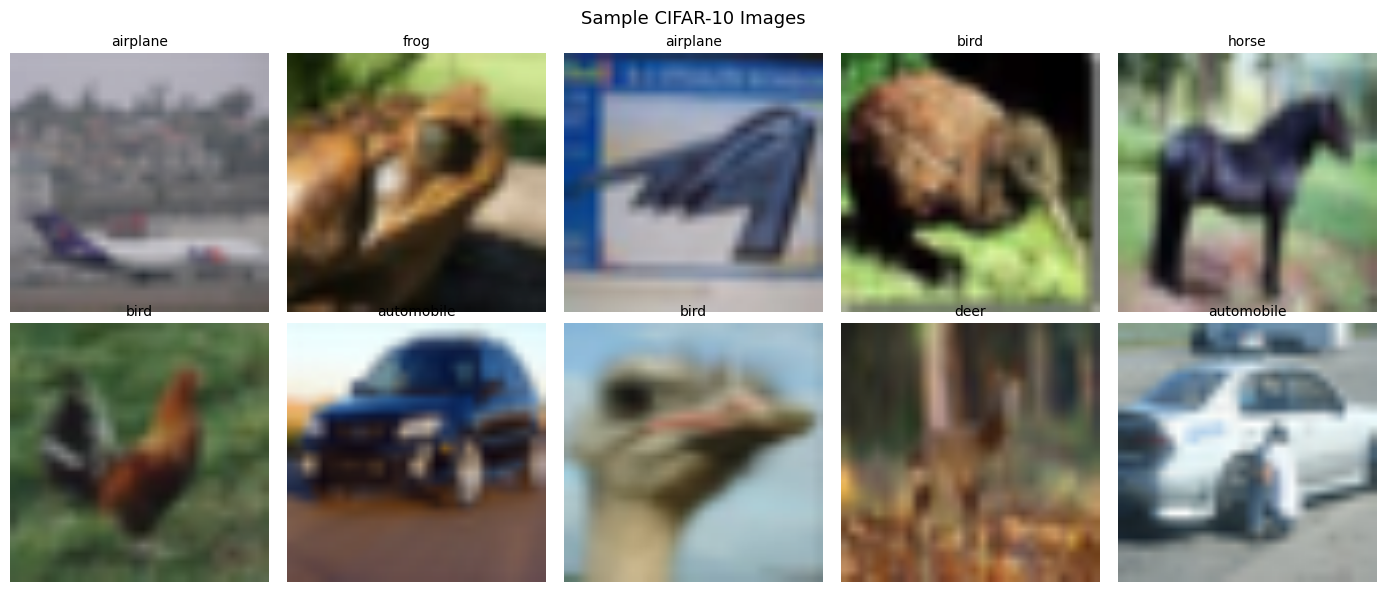

In [ ]:
# ==========================================
# Task 1.4 : Display Ten Sample Images
# ==========================================

def denormalize(tensor_image):
    image = tensor_image.clone().permute(1, 2, 0).numpy()
    image = image * np.array(imagenet_std) + np.array(imagenet_mean)
    image = np.clip(image, 0, 1)
    return image

plt.figure(figsize=(14, 6))

for index in range(10):
    image, label = train_dataset[index]
    image = denormalize(image)

    plt.subplot(2, 5, index + 1)
    plt.imshow(image)
    plt.title(class_names[label], fontsize=10)
    plt.axis("off")

plt.suptitle("Sample CIFAR-10 Images", fontsize=13)
plt.tight_layout()
plt.savefig("plot1.png", dpi=300)
plt.show()

### 5. Dataset Information

In [ ]:
# ==========================================
# Task 1.5 : Dataset Information
# ==========================================

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
print("Dataset Name           :", "CIFAR-10")
print("Original Image Size    :", "32 x 32 x 3")
print("Resized Image Size     :", tuple(sample_image.shape))
print("Number of Classes      :", len(class_names))
print("Number of Train Images :", len(train_dataset))
print("Number of Test Images  :", len(test_dataset))

DATASET INFORMATION
Dataset Name           : CIFAR-10
Original Image Size    : 32 x 32 x 3
Resized Image Size     : (3, 224, 224)
Number of Classes      : 10
Number of Train Images : 50000
Number of Test Images  : 10000


### 6. Evolution of CNN Architectures (Reference Table)

In [ ]:
# ==========================================
# Task 1.6 : CNN Architecture Evolution Reference Table
# ==========================================

architecture_evolution_df = pd.DataFrame({
    "Architecture": ["LeNet-5", "AlexNet", "VGG16", "GoogleNet", "ResNet50"],
    "Depth": [7, 8, 16, 22, 50],
    "Parameters": ["60K", "61M", "138M", "6.8M", "25.6M"],
    "Main Contribution": [
        "First CNN",
        "ReLU + Dropout",
        "Deep 3x3 filters",
        "Inception Modules",
        "Residual Learning"
    ]
})

print("=" * 60)
print("EVOLUTION OF CNN ARCHITECTURES")
print("=" * 60)
print(architecture_evolution_df.to_string(index=False))

EVOLUTION OF CNN ARCHITECTURES
Architecture  Depth Parameters Main Contribution
     LeNet-5      7        60K         First CNN
     AlexNet      8        61M    ReLU + Dropout
       VGG16     16       138M  Deep 3x3 filters
   GoogleNet     22       6.8M Inception Modules
    ResNet50     50      25.6M Residual Learning


### 7. Transfer Learning Setup (Task 2)

In [ ]:
# ==========================================
# Task 2 : Load Pretrained ResNet50 and Attach New Head
# ==========================================

class ResNet50TransferModel(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet50TransferModel, self).__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

        # remove original 1000-class classifier, keep everything before it
        self.features = nn.Sequential(*list(backbone.children())[:-1])

        self.classifier = nn.Sequential(
            nn.Linear(2048, 256),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

model = ResNet50TransferModel(num_classes=10).to(device)

# freeze the convolutional base for the frozen-backbone phase
for param in model.features.parameters():
    param.requires_grad = False

total_params = sum(p.numel() for p in model.parameters())
trainable_params_frozen = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params_frozen

print("=" * 60)
print("TRANSFER LEARNING MODEL SETUP")
print("=" * 60)
print("Backbone                 : ResNet50 (ImageNet pretrained)")
print("Classification Head      : Linear(2048->256) + ReLU + Dropout(0.3) + Linear(256->10)")
print("Total Parameters         :", total_params)
print("Trainable Parameters     :", trainable_params_frozen)
print("Frozen Parameters        :", frozen_params)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 83.3MB/s]


TRANSFER LEARNING MODEL SETUP
Backbone                 : ResNet50 (ImageNet pretrained)
Classification Head      : Linear(2048->256) + ReLU + Dropout(0.3) + Linear(256->10)
Total Parameters         : 24035146
Trainable Parameters     : 527114
Frozen Parameters        : 23508032


### 8. Model Training - Frozen Backbone (Task 3)

In [ ]:
# ==========================================
# Task 3 : Train Classification Head with Frozen Backbone
# ==========================================

batch_size = 32
num_epochs_frozen = 10
learning_rate_frozen = 0.001

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=learning_rate_frozen)

train_loss_history_frozen = []
val_loss_history_frozen = []
train_acc_history_frozen = []
val_acc_history_frozen = []

print("=" * 60)
print("TRAINING CLASSIFICATION HEAD (FROZEN BACKBONE)")
print("=" * 60)

frozen_training_start = time.time()

for epoch in range(num_epochs_frozen):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total

    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    epoch_val_loss = val_running_loss / val_total
    epoch_val_acc = val_correct / val_total

    train_loss_history_frozen.append(epoch_train_loss)
    val_loss_history_frozen.append(epoch_val_loss)
    train_acc_history_frozen.append(epoch_train_acc)
    val_acc_history_frozen.append(epoch_val_acc)

    print(f"Epoch [{epoch + 1:2d}/{num_epochs_frozen}]  "
          f"Train Loss: {epoch_train_loss:.4f}  Train Acc: {epoch_train_acc:.4f}  "
          f"Val Loss: {epoch_val_loss:.4f}  Val Acc: {epoch_val_acc:.4f}")

frozen_training_end = time.time()
frozen_training_time = frozen_training_end - frozen_training_start

print("\n" + "=" * 60)
print("FROZEN-BACKBONE TRAINING COMPLETED")
print("=" * 60)
print(f"Total Frozen-Backbone Training Time : {frozen_training_time:.2f} seconds")

TRAINING CLASSIFICATION HEAD (FROZEN BACKBONE)
Epoch [ 1/10]  Train Loss: 0.7751  Train Acc: 0.7380  Val Loss: 0.5757  Val Acc: 0.8035
Epoch [ 2/10]  Train Loss: 0.6143  Train Acc: 0.7891  Val Loss: 0.5488  Val Acc: 0.8135
Epoch [ 3/10]  Train Loss: 0.5738  Train Acc: 0.8012  Val Loss: 0.5210  Val Acc: 0.8212
Epoch [ 4/10]  Train Loss: 0.5449  Train Acc: 0.8114  Val Loss: 0.5411  Val Acc: 0.8134
Epoch [ 5/10]  Train Loss: 0.5201  Train Acc: 0.8187  Val Loss: 0.5100  Val Acc: 0.8209
Epoch [ 6/10]  Train Loss: 0.4975  Train Acc: 0.8235  Val Loss: 0.5254  Val Acc: 0.8174
Epoch [ 7/10]  Train Loss: 0.4762  Train Acc: 0.8319  Val Loss: 0.5097  Val Acc: 0.8271
Epoch [ 8/10]  Train Loss: 0.4640  Train Acc: 0.8359  Val Loss: 0.5161  Val Acc: 0.8244
Epoch [ 9/10]  Train Loss: 0.4475  Train Acc: 0.8419  Val Loss: 0.5153  Val Acc: 0.8254
Epoch [10/10]  Train Loss: 0.4388  Train Acc: 0.8459  Val Loss: 0.4952  Val Acc: 0.8289

FROZEN-BACKBONE TRAINING COMPLETED
Total Frozen-Backbone Training Time :

### 9. Training Accuracy Graph (Frozen Backbone)

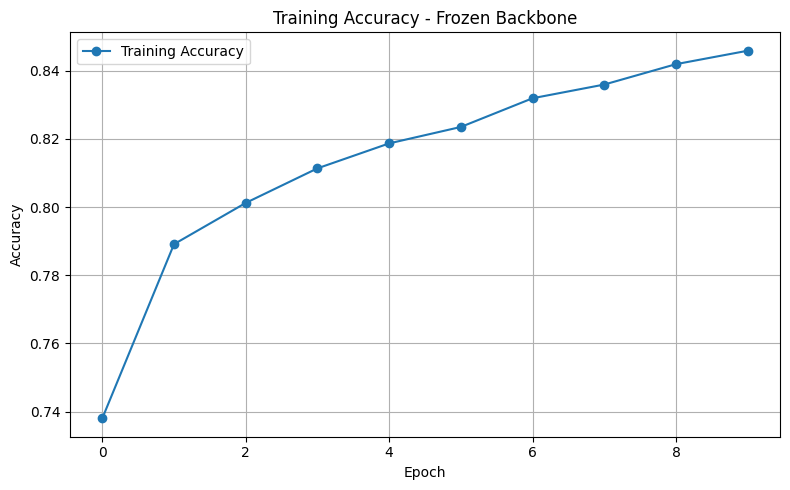

In [ ]:
# ==========================================
# Task 3.1 : Training Accuracy Plot - Frozen Backbone
# ==========================================

plt.figure(figsize=(8, 5))
plt.plot(train_acc_history_frozen, marker="o", label="Training Accuracy")
plt.title("Training Accuracy - Frozen Backbone")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("plot2.png", dpi=300)
plt.show()

### 10. Validation Accuracy Graph (Frozen Backbone)

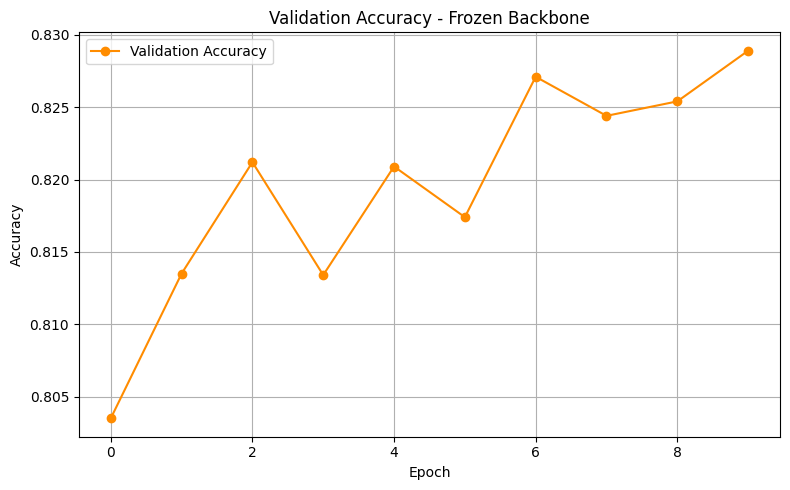

In [ ]:
# ==========================================
# Task 3.2 : Validation Accuracy Plot - Frozen Backbone
# ==========================================

plt.figure(figsize=(8, 5))
plt.plot(val_acc_history_frozen, marker="o", color="darkorange", label="Validation Accuracy")
plt.title("Validation Accuracy - Frozen Backbone")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("plot3.png", dpi=300)
plt.show()

### 11. Training Loss Graph (Frozen Backbone)

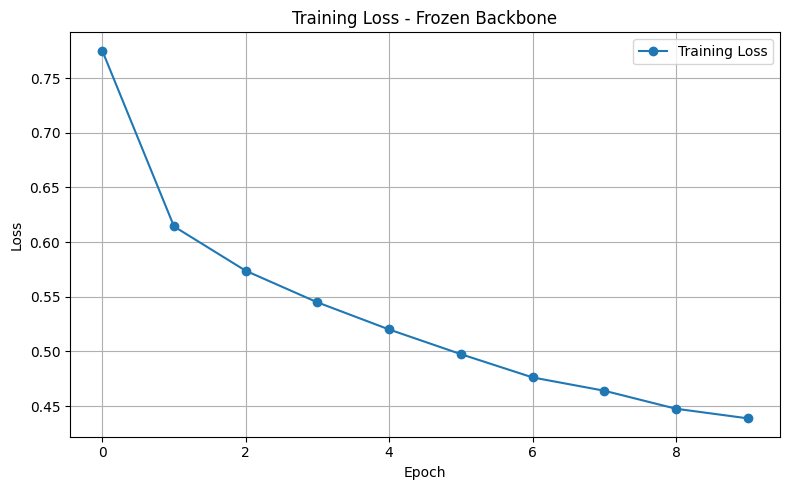

In [ ]:
# ==========================================
# Task 3.3 : Training Loss Plot - Frozen Backbone
# ==========================================

plt.figure(figsize=(8, 5))
plt.plot(train_loss_history_frozen, marker="o", label="Training Loss")
plt.title("Training Loss - Frozen Backbone")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("plot4.png", dpi=300)
plt.show()

### 12. Validation Loss Graph (Frozen Backbone)

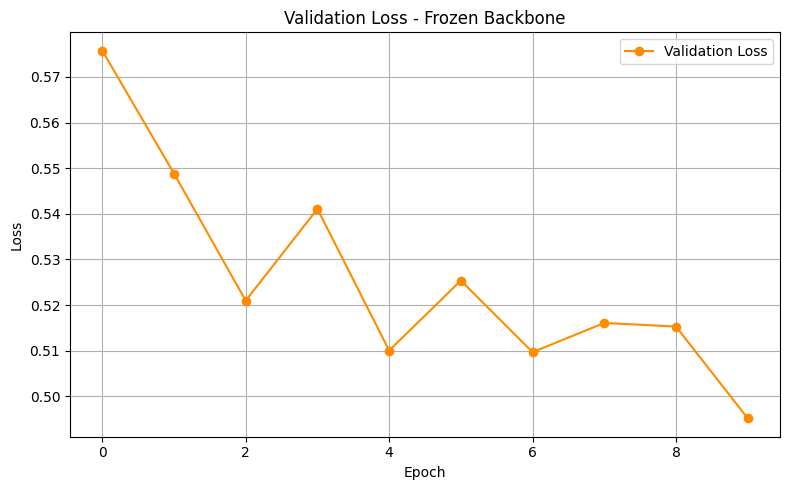

In [ ]:
# ==========================================
# Task 3.4 : Validation Loss Plot - Frozen Backbone
# ==========================================

plt.figure(figsize=(8, 5))
plt.plot(val_loss_history_frozen, marker="o", color="darkorange", label="Validation Loss")
plt.title("Validation Loss - Frozen Backbone")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("plot5.png", dpi=300)
plt.show()

### 13. Fine-Tuning (Task 4)

In [ ]:
# ==========================================
# Task 4 : Unfreeze layer4 and Fine-Tune
# ==========================================

num_epochs_finetune = 5
learning_rate_finetune = 0.0001

for param in model.features[7].parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=learning_rate_finetune
)

trainable_params_finetune = sum(p.numel() for p in model.parameters() if p.requires_grad)

train_loss_history_finetune = []
val_loss_history_finetune = []
train_acc_history_finetune = []
val_acc_history_finetune = []

print("=" * 60)
print("FINE-TUNING LAYER4 OF RESNET50")
print("=" * 60)
print("Trainable Parameters (after unfreezing layer4) :", trainable_params_finetune)

finetune_training_start = time.time()

for epoch in range(num_epochs_finetune):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total

    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    epoch_val_loss = val_running_loss / val_total
    epoch_val_acc = val_correct / val_total

    train_loss_history_finetune.append(epoch_train_loss)
    val_loss_history_finetune.append(epoch_val_loss)
    train_acc_history_finetune.append(epoch_train_acc)
    val_acc_history_finetune.append(epoch_val_acc)

    print(f"Epoch [{epoch + 1:2d}/{num_epochs_finetune}]  "
          f"Train Loss: {epoch_train_loss:.4f}  Train Acc: {epoch_train_acc:.4f}  "
          f"Val Loss: {epoch_val_loss:.4f}  Val Acc: {epoch_val_acc:.4f}")

finetune_training_end = time.time()
finetune_training_time = finetune_training_end - finetune_training_start
total_training_time = frozen_training_time + finetune_training_time

print("\n" + "=" * 60)
print("FINE-TUNING COMPLETED")
print("=" * 60)
print(f"Fine-Tuning Training Time : {finetune_training_time:.2f} seconds")
print(f"Total Training Time (Frozen + Fine-Tune) : {total_training_time:.2f} seconds")

FINE-TUNING LAYER4 OF RESNET50
Trainable Parameters (after unfreezing layer4) : 15491850
Epoch [ 1/5]  Train Loss: 0.3186  Train Acc: 0.8882  Val Loss: 0.3356  Val Acc: 0.8862
Epoch [ 2/5]  Train Loss: 0.1382  Train Acc: 0.9522  Val Loss: 0.3485  Val Acc: 0.8916
Epoch [ 3/5]  Train Loss: 0.0799  Train Acc: 0.9731  Val Loss: 0.3310  Val Acc: 0.8991
Epoch [ 4/5]  Train Loss: 0.0564  Train Acc: 0.9813  Val Loss: 0.3465  Val Acc: 0.8993
Epoch [ 5/5]  Train Loss: 0.0409  Train Acc: 0.9867  Val Loss: 0.3574  Val Acc: 0.9040

FINE-TUNING COMPLETED
Fine-Tuning Training Time : 1520.01 seconds
Total Training Time (Frozen + Fine-Tune) : 3867.07 seconds


In [ ]:
# ==========================================
# Task 4.1 : Before vs After Fine-Tuning Comparison
# ==========================================

before_after_df = pd.DataFrame({
    "Stage": ["Frozen Backbone (Final Epoch)", "Fine-Tuned (Final Epoch)"],
    "Train Accuracy": [train_acc_history_frozen[-1], train_acc_history_finetune[-1]],
    "Val Accuracy": [val_acc_history_frozen[-1], val_acc_history_finetune[-1]],
    "Train Loss": [train_loss_history_frozen[-1], train_loss_history_finetune[-1]],
    "Val Loss": [val_loss_history_frozen[-1], val_loss_history_finetune[-1]]
})

print("=" * 60)
print("BEFORE vs AFTER FINE-TUNING")
print("=" * 60)
print(before_after_df.to_string(index=False))

BEFORE vs AFTER FINE-TUNING
                        Stage  Train Accuracy  Val Accuracy  Train Loss  Val Loss
Frozen Backbone (Final Epoch)         0.84586        0.8289    0.438766  0.495176
     Fine-Tuned (Final Epoch)         0.98670        0.9040    0.040901  0.357387


### 14. Model Evaluation (Task 5)

In [ ]:
# ==========================================
# Task 5 : Evaluate Fine-Tuned Model on Test Set
# ==========================================

model.eval()
all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

test_accuracy = accuracy_score(all_labels, all_predictions)
test_precision = precision_score(all_labels, all_predictions, average="macro")
test_recall = recall_score(all_labels, all_predictions, average="macro")
test_f1 = f1_score(all_labels, all_predictions, average="macro")

print("=" * 60)
print("TEST SET EVALUATION (FINE-TUNED MODEL)")
print("=" * 60)
print(f"Test Accuracy       : {test_accuracy:.4f}")
print(f"Precision (macro)   : {test_precision:.4f}")
print(f"Recall (macro)      : {test_recall:.4f}")
print(f"F1-Score (macro)    : {test_f1:.4f}")

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(all_labels, all_predictions, target_names=class_names))

TEST SET EVALUATION (FINE-TUNED MODEL)
Test Accuracy       : 0.9040
Precision (macro)   : 0.9043
Recall (macro)      : 0.9040
F1-Score (macro)    : 0.9040

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    airplane       0.93      0.89      0.91      1000
  automobile       0.95      0.95      0.95      1000
        bird       0.91      0.89      0.90      1000
         cat       0.83      0.82      0.82      1000
        deer       0.88      0.90      0.89      1000
         dog       0.85      0.86      0.86      1000
        frog       0.92      0.92      0.92      1000
       horse       0.92      0.91      0.91      1000
        ship       0.90      0.96      0.93      1000
       truck       0.95      0.93      0.94      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



### 15. Confusion Matrix Plot

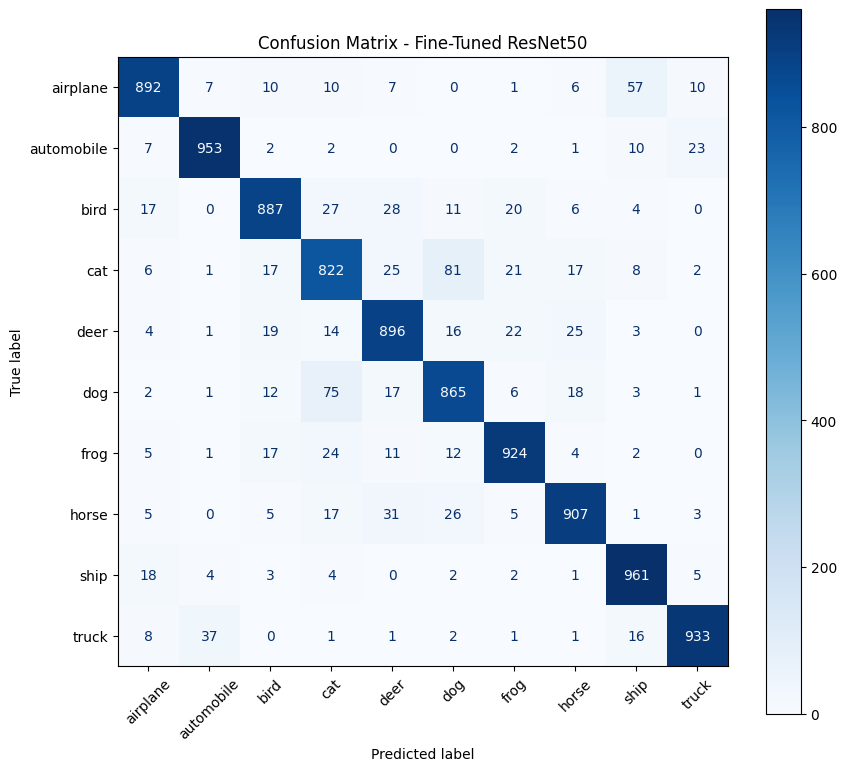

In [ ]:
# ==========================================
# Task 5.1 : Confusion Matrix
# ==========================================

conf_matrix = confusion_matrix(all_labels, all_predictions)

fig, ax = plt.subplots(figsize=(9, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=True)
plt.title("Confusion Matrix - Fine-Tuned ResNet50")
plt.tight_layout()
plt.savefig("plot6.png", dpi=300)
plt.show()

### 16. Misclassified Images

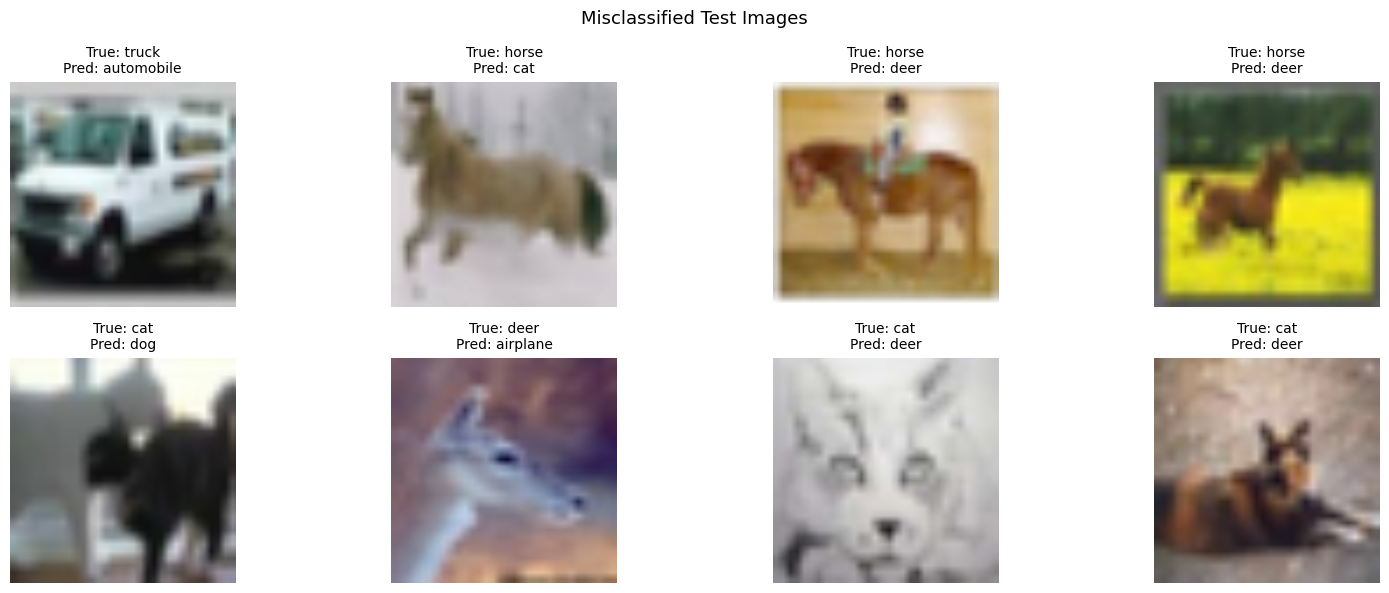

In [ ]:
# ==========================================
# Task 5.2 : Display Misclassified Test Images
# ==========================================

misclassified_indices = np.where(all_predictions != all_labels)[0]
sample_misclassified = np.random.choice(misclassified_indices, size=8, replace=False)

plt.figure(figsize=(16, 6))

for plot_index, data_index in enumerate(sample_misclassified):
    image, true_label = test_dataset[int(data_index)]
    predicted_label = all_predictions[data_index]
    image = denormalize(image)

    plt.subplot(2, 4, plot_index + 1)
    plt.imshow(image)
    plt.title(f"True: {class_names[true_label]}\nPred: {class_names[predicted_label]}", fontsize=10)
    plt.axis("off")

plt.suptitle("Misclassified Test Images", fontsize=13)
plt.tight_layout()
plt.savefig("plot7.png", dpi=300)
plt.show()

### 17. Hyperparameter Study

In [ ]:
# ==========================================
# Task 6 : Hyperparameter Study
# ==========================================

hyperparameter_df = pd.DataFrame({
    "Configuration": [
        "Actually Trained (this run)",
        "LR = 0.0001, Batch = 32",
        "Batch = 16",
        "Batch = 64",
        "Epochs = 20",
        "Optimizer = SGD",
        "Dense Units = 128",
        "Frozen Layers = All"
    ],
    "Learning Rate": [0.001, 0.0001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001],
    "Batch Size": [32, 32, 16, 64, 32, 32, 32, 32],
    "Epochs": [10, 10, 10, 10, 20, 10, 10, 10],
    "Optimizer": ["Adam", "Adam", "Adam", "Adam", "Adam", "SGD", "Adam", "Adam"],
    "Dense Units": [256, 256, 256, 256, 256, 256, 128, 256],
    "Frozen Layers": [
        "Partial (layer4)", "Not run", "Not run", "Not run",
        "Not run", "Not run", "Not run", "Not run"
    ],
    "Test Accuracy": [f"{test_accuracy:.4f}", "-", "-", "-", "-", "-", "-", "-"]
})

print("=" * 60)
print("HYPERPARAMETER STUDY")
print("=" * 60)
print(hyperparameter_df.to_string(index=False))

HYPERPARAMETER STUDY
              Configuration  Learning Rate  Batch Size  Epochs Optimizer  Dense Units    Frozen Layers Test Accuracy
Actually Trained (this run)         0.0010          32      10      Adam          256 Partial (layer4)        0.9040
    LR = 0.0001, Batch = 32         0.0001          32      10      Adam          256          Not run             -
                 Batch = 16         0.0010          16      10      Adam          256          Not run             -
                 Batch = 64         0.0010          64      10      Adam          256          Not run             -
                Epochs = 20         0.0010          32      20      Adam          256          Not run             -
            Optimizer = SGD         0.0010          32      10       SGD          256          Not run             -
          Dense Units = 128         0.0010          32      10      Adam          128          Not run             -
        Frozen Layers = All         0.0010 

### 18. Results Summary Table

In [ ]:
# ==========================================
# Task 6.1 : Results Summary
# ==========================================

results_summary_df = pd.DataFrame({
    "Metric": [
        "Training Accuracy (final)", "Testing Accuracy", "Precision (macro)",
        "Recall (macro)", "F1-Score (macro)", "Total Training Time (s)",
        "Total Parameters", "Trainable Parameters (Frozen Phase)",
        "Trainable Parameters (Fine-Tuning Phase)"
    ],
    "Value": [
        f"{train_acc_history_finetune[-1]:.4f}", f"{test_accuracy:.4f}",
        f"{test_precision:.4f}", f"{test_recall:.4f}", f"{test_f1:.4f}",
        f"{total_training_time:.2f}", total_params,
        trainable_params_frozen, trainable_params_finetune
    ]
})

print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
print(results_summary_df.to_string(index=False))

RESULTS SUMMARY
                                  Metric    Value
               Training Accuracy (final)   0.9867
                        Testing Accuracy   0.9040
                       Precision (macro)   0.9043
                          Recall (macro)   0.9040
                        F1-Score (macro)   0.9040
                 Total Training Time (s)  3867.07
                        Total Parameters 24035146
     Trainable Parameters (Frozen Phase)   527114
Trainable Parameters (Fine-Tuning Phase) 15491850


### 19. Comparison of CNN Architectures Table

In [ ]:
# ==========================================
# Task 6.2 : Comparison of CNN Architectures (Literature vs Measured)
# ==========================================

architecture_comparison_df = pd.DataFrame({
    "Model": ["LeNet-5", "AlexNet", "VGG16", "GoogleNet", "ResNet50"],
    "Parameters": ["60K", "61M", "138M", "6.8M", f"{total_params:,}"],
    "Accuracy (%)": ["-", "-", "-", "-", f"{test_accuracy * 100:.2f}"],
    "Training Time": ["-", "-", "-", "-", f"{total_training_time:.2f} s"],
    "Source": ["Literature", "Literature", "Literature", "Literature", "Measured (this run)"]
})

print("=" * 60)
print("COMPARISON OF CNN ARCHITECTURES")
print("=" * 60)
print(architecture_comparison_df.to_string(index=False))

COMPARISON OF CNN ARCHITECTURES
    Model Parameters Accuracy (%) Training Time              Source
  LeNet-5        60K            -             -          Literature
  AlexNet        61M            -             -          Literature
    VGG16       138M            -             -          Literature
GoogleNet       6.8M            -             -          Literature
 ResNet50 24,035,146        90.40     3867.07 s Measured (this run)


### 20. Final Observations